Importing the libraries

In [ ]:
# 1. Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy as sp
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')

# Set aesthetic visual theme
sns.set_theme(style="whitegrid")

Data Loading & Inspection

In [ ]:
# Load dataset directly from repository
df=pd.read_csv("/content/usedcarpricing.csv",index_col=0)

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

First 5 rows:
                               Name    Location  Year  Kilometers_Driven  \
0            Maruti Wagon R LXI CNG      Mumbai  2010              72000   
1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015              41000   
2                      Honda Jazz V     Chennai  2011              46000   
3                 Maruti Ertiga VDI     Chennai  2012              87000   
4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013              40670   

  Fuel_Type Transmission Owner_Type     Mileage   Engine      Power  Seats  \
0       CNG       Manual      First  26.6 km/kg   998 CC  58.16 bhp    5.0   
1    Diesel       Manual      First  19.67 kmpl  1582 CC  126.2 bhp    5.0   
2    Petrol       Manual      First   18.2 kmpl  1199 CC   88.7 bhp    5.0   
3    Diesel       Manual      First  20.77 kmpl  1248 CC  88.76 bhp    7.0   
4    Diesel    Automatic     Second   15.2 kmpl  1968 CC  140.8 bhp    5.0   

   New_Price  Price  
0        NaN   1.75  
1        NaN  12

In [ ]:
# Check dataset column information and null values
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   object 
 8   Engine             5983 non-null   object 
 9   Power              5983 non-null   object 
 10  Seats              5977 non-null   float64
 11  New_Price          824 non-null    object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 658.3+ KB

Missing values per column:
Name                    0
Location                0
Year                    0
Kilomete

Data Cleaning & Feature Extraction

In [ ]:
# Drop high-missing or non-predictive columns
df.drop(columns=['Unnamed: 0', 'New_Price', 'Location'], inplace=True, errors='ignore')

# Drop duplicate rows if present
print("Duplicate count:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Extract Manufacturer from 'Name'
df['Manufacturer'] = df['Name'].astype(str).str.split().str[0]
df.drop(columns=['Name'], inplace=True)

# Transform 'Year' into 'Car_Age'
current_year = pd.datetime.now().year if hasattr(pd, 'datetime') else 2026
df['Car_Age'] = current_year - df['Year']
df.drop(columns=['Year'], inplace=True)

# Parse string values to numeric numbers
df['Mileage'] = pd.to_numeric(df['Mileage'].astype(str).str.split().str[0], errors='coerce')
df['Engine'] = pd.to_numeric(df['Engine'].astype(str).str.split().str[0], errors='coerce')
df['Power'] = pd.to_numeric(df['Power'].astype(str).str.split().str[0], errors='coerce')

# Impute numerical missing values with median
num_impute_cols = ['Mileage', 'Engine', 'Power', 'Seats']
for col in num_impute_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("\nCleaned Dataset Preview:")
print(df.head())

Duplicate count: 0

Cleaned Dataset Preview:
   Kilometers_Driven Fuel_Type Transmission Owner_Type  Mileage  Engine  \
0              72000       CNG       Manual      First    26.60   998.0   
1              41000    Diesel       Manual      First    19.67  1582.0   
2              46000    Petrol       Manual      First    18.20  1199.0   
3              87000    Diesel       Manual      First    20.77  1248.0   
4              40670    Diesel    Automatic     Second    15.20  1968.0   

    Power  Seats  Price Manufacturer  Car_Age  
0   58.16    5.0   1.75       Maruti       16  
1  126.20    5.0  12.50      Hyundai       11  
2   88.70    5.0   4.50        Honda       15  
3   88.76    7.0   6.00       Maruti       14  
4  140.80    5.0  17.74         Audi       13  


Categorical Breakdown & Summary Statistics

In [ ]:
# Summary statistics for numerical variables
print(df.describe())

# Identifying categorical and numerical features
num_features = [f for f in df.columns if df[f].dtype != 'O']
cat_features = [f for f in df.columns if df[f].dtype == 'O']

print(f'\nNumerical features ({len(num_features)}):', num_features)
print(f'Categorical features ({len(cat_features)}):', cat_features)

       Kilometers_Driven      Mileage       Engine        Power        Seats  \
count       6.019000e+03  6019.000000  6019.000000  6019.000000  6019.000000   
mean        5.873838e+04    18.134966  1620.509221   112.883539     5.276790   
std         9.126884e+04     4.581528   599.635458    53.283701     0.806346   
min         1.710000e+02     0.000000    72.000000    34.200000     0.000000   
25%         3.400000e+04    15.170000  1198.000000    78.000000     5.000000   
50%         5.300000e+04    18.150000  1493.000000    97.700000     5.000000   
75%         7.300000e+04    21.100000  1969.000000   138.030000     5.000000   
max         6.500000e+06    33.540000  5998.000000   560.000000    10.000000   

             Price      Car_Age  
count  6019.000000  6019.000000  
mean      9.479468    12.641801  
std      11.187917     3.269742  
min       0.440000     7.000000  
25%       3.500000    10.000000  
50%       5.640000    12.000000  
75%       9.950000    15.000000  
max    

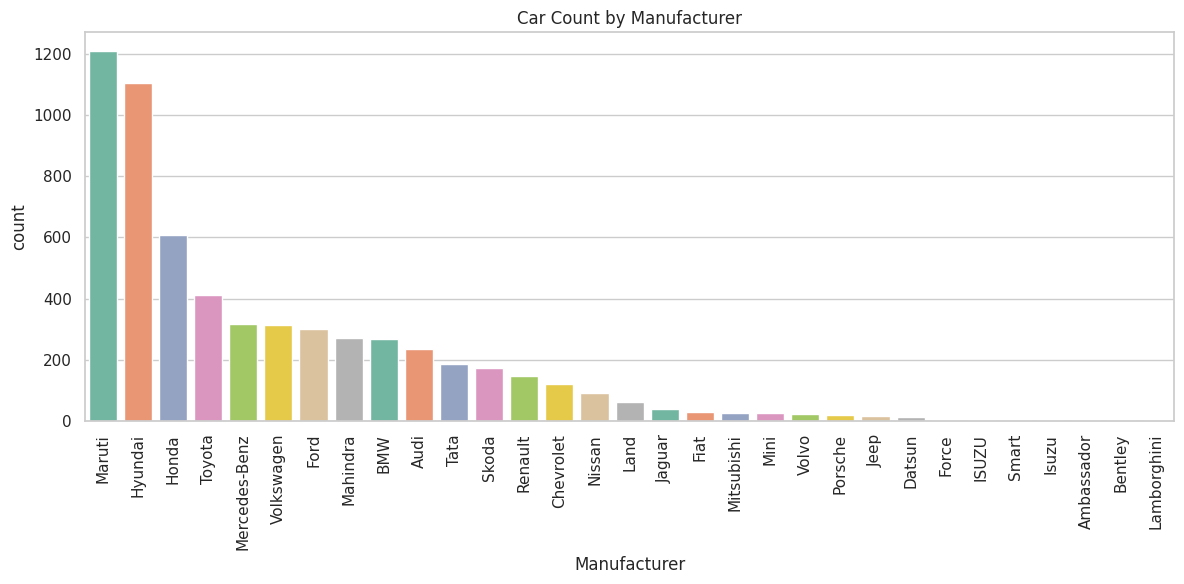

In [ ]:
# Manufacturer count plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Manufacturer', order=df['Manufacturer'].value_counts().index, palette='Set2')
plt.xticks(rotation=90)
plt.title("Car Count by Manufacturer")
plt.tight_layout()
plt.show()

Outlier Detection & Trimming (Kilometers Driven)

In [ ]:
# Check distribution and skewness of Kilometers_Driven
print("Kilometers_Driven Skewness:", df['Kilometers_Driven'].skew())

# Outlier removal using the Interquartile Range (IQR) method
Q1 = df['Kilometers_Driven'].quantile(0.25)
Q3 = df['Kilometers_Driven'].quantile(0.75)
IQR = Q3 - Q1

lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

df = df[(df['Kilometers_Driven'] >= lb) & (df['Kilometers_Driven'] <= ub)]
print("Shape after trimming Kilometers_Driven outliers:", df.shape)

Kilometers_Driven Skewness: 58.72466188582937
Shape after trimming Kilometers_Driven outliers: (5817, 11)


One-Hot Encoding Categorical Variables

In [ ]:
# Separate numerical and categorical data
num_data = df[num_features]
cat_data = df[cat_features]

# One-hot encoding categorical variables
cat_data_encoded = pd.get_dummies(cat_data, drop_first=True, dtype=np.int32)

# Recombine numerical and encoded categorical features
df_processed = pd.concat([num_data, cat_data_encoded], axis=1)
print("Processed Dataset Shape:", df_processed.shape)

Processed Dataset Shape: (5817, 45)


Influential Points Removal via Cook's Distance

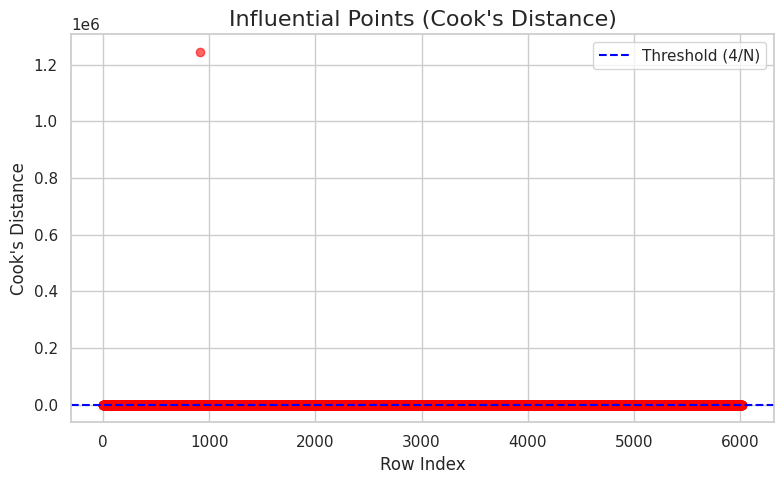

Identified 286 influential data points.
Shape after dropping influential points: (5531, 45)


In [ ]:
X_initial = df_processed.drop(columns=['Price'])
y_initial = df_processed['Price']

# Fit OLS model to detect influential points
X_const = sm.add_constant(X_initial)
ols_initial = sm.OLS(y_initial, X_const).fit()

# Calculate Cook's distance
influence = ols_initial.get_influence()
cooks = influence.cooks_distance[0]

# Plot Cook's Distance
plt.figure(figsize=(8, 5))
plt.scatter(df_processed.index, cooks, color='red', alpha=0.6)
plt.xlabel("Row Index", fontsize=12)
plt.ylabel("Cook's Distance", fontsize=12)
plt.title("Influential Points (Cook's Distance)", fontsize=16)
plt.axhline(y=4/len(df_processed), color='blue', linestyle='--', label='Threshold (4/N)')
plt.legend()
plt.tight_layout()
plt.show()

# Filter out influential points exceeding threshold
influential_points = df_processed.index[cooks > (4 / len(df_processed))]
print(f"Identified {len(influential_points)} influential data points.")

df_clean = df_processed.drop(index=influential_points)
print("Shape after dropping influential points:", df_clean.shape)

Regression Assumptions Diagnostics

In [ ]:
# Prepare cleaned features and target
X = df_clean.drop(columns=['Price'])
y = df_clean['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Fit Baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

print(f"Training R² = {r2_score(y_train, y_train_pred):.4f}")
print(f"Testing R²  = {r2_score(y_test, y_test_pred):.4f}")

Training R² = 0.8643
Testing R²  = 0.8550


Before removing the influential points, the r2  score on baseline linear model was lower. After removing Cook's distance influential points(Cook's D>(4/N)), the r2 score increased up to 0.864 on training and 0.855 on test set.

1: Linearity

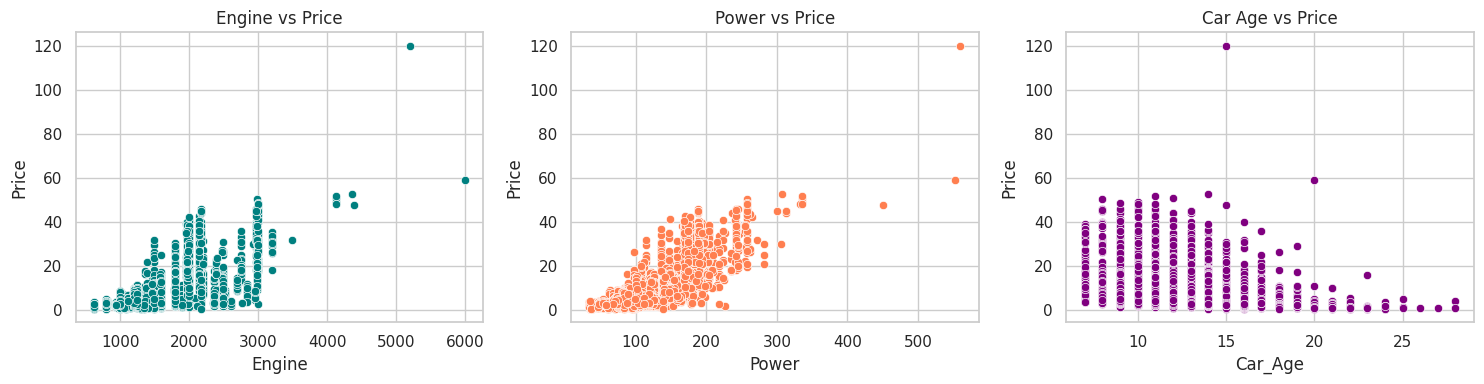

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x=df_clean['Engine'], y=df_clean['Price'], ax=ax1, color='teal')
ax1.set_title("Engine vs Price")

sns.scatterplot(x=df_clean['Power'], y=df_clean['Price'], ax=ax2, color='coral')
ax2.set_title("Power vs Price")

sns.scatterplot(x=df_clean['Car_Age'], y=df_clean['Price'], ax=ax3, color='purple')
ax3.set_title("Car Age vs Price")

plt.tight_layout()
plt.show()

In [ ]:
Linearity exists somewhat between core continuous predictors (Engine, Power, Car Age) and car prices

2: Normality of Residuals

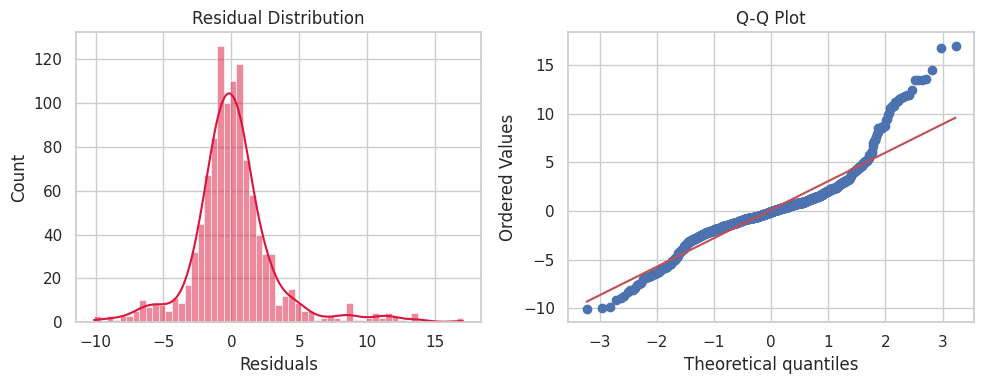

Shapiro-Wilk Statistic : 0.8874
p-value                : 1.2335e-27
Conclusion: Residuals reject normality (p < 0.05).


In [ ]:
residuals = y_test - y_test_pred

# Residual Histogram & KDE
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='crimson')
plt.xlabel("Residuals")
plt.title("Residual Distribution")

# Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.tight_layout()
plt.show()

# Shapiro-Wilk Test
statistic, p_value = stats.shapiro(residuals)
print(f"Shapiro-Wilk Statistic : {statistic:.4f}")
print(f"p-value                : {p_value:.4e}")
if p_value < 0.05:
    print("Conclusion: Residuals reject normality (p < 0.05).")

Since p-value < 0.05, H0is rejected, indicating residuals are not strictly normally distributed due to high-value luxury cars.

3: Homoscedasticity

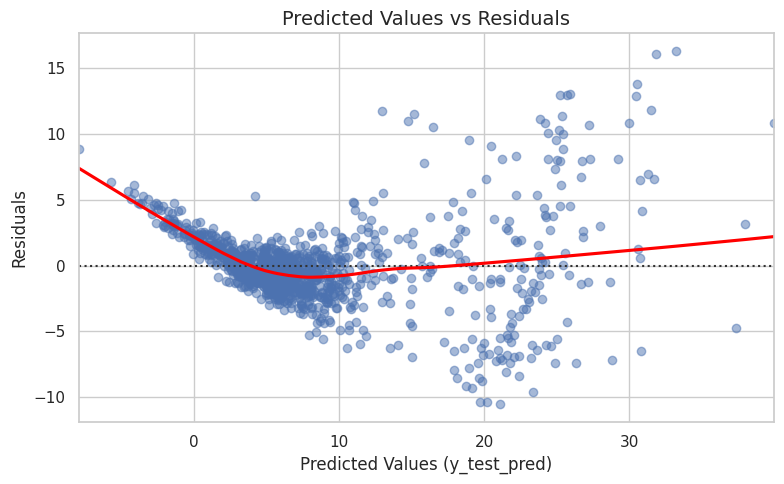

In [ ]:
plt.figure(figsize=(8, 5))
sns.residplot(x=y_test_pred, y=residuals, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel("Predicted Values (y_test_pred)", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Predicted Values vs Residuals", fontsize=14)
plt.tight_layout()
plt.show()

As seen from the plot, we cannot find a strong pattern between the residuals and Y_test_pred, therefore error variance is homoscedastic

4: Multicollinearity (VIF Factor)

In [ ]:
# Compute VIF for top numerical predictor columns
vif_features = ['Car_Age', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
vif_df = pd.DataFrame()
vif_df["features"] = vif_features
vif_df["VIF Factor"] = [
    variance_inflation_factor(X[vif_features].values, i)
    for i in range(len(vif_features))
]

print("Variance Inflation Factor (VIF):")
print(vif_df)

Variance Inflation Factor (VIF):
            features  VIF Factor
0            Car_Age    1.675629
1  Kilometers_Driven    1.514813
2            Mileage    1.822686
3             Engine    6.271458
4              Power    4.844041
5              Seats    1.752742


Although Engine has a VIF value slightly above 5 due to correlation with Power, the overall correlation heatmap confirms there is no extreme collinearity affecting prediction stability.

Multi-Model Performance Benchmarking

In [ ]:
def evaluate_model(true, predicted, n, p):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return mae, mse, r2, rmse, adjusted_r2

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

model_list = []
r2_list = []
adjusted_r2_list = []
cv_scores = []

for name, model in models.items():
    # Training model on scaled data
    model.fit(X_train_scaled, y_train)

    # Predicting
    y_tr_pred = model.predict(X_train_scaled)
    y_te_pred = model.predict(X_test_scaled)

    # Evaluations
    n_tr, p_tr = X_train_scaled.shape
    n_te, p_te = X_test_scaled.shape

    tr_mae, tr_mse, tr_r2, tr_rmse, tr_adj_r2 = evaluate_model(y_train, y_tr_pred, n_tr, p_tr)
    te_mae, te_mse, te_r2, te_rmse, te_adj_r2 = evaluate_model(y_test, y_te_pred, n_te, p_te)

    # 5-Fold Cross-Validation Score
    cv_score = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='r2').mean()

    model_list.append(name)
    r2_list.append(te_r2)
    adjusted_r2_list.append(te_adj_r2)
    cv_scores.append(cv_score)

    print(f"=== {name} ===")
    print("Training Set Metrics:")
    print(f"  - RMSE        : {tr_rmse:.4f}")
    print(f"  - MAE         : {tr_mae:.4f}")
    print(f"  - R² Score    : {tr_r2:.4f}")
    print(f"  - Adj R² Score: {tr_adj_r2:.4f}")
    print("Test Set Metrics:")
    print(f"  - RMSE        : {te_rmse:.4f}")
    print(f"  - MAE         : {te_mae:.4f}")
    print(f"  - R² Score    : {te_r2:.4f}")
    print(f"  - Adj R² Score: {te_adj_r2:.4f}")
    print(f"  - 5-Fold CV R²: {cv_score:.4f}")
    print("=" * 40 + "\n")

=== Linear Regression ===
Training Set Metrics:
  - RMSE        : 3.0741
  - MAE         : 2.0292
  - R² Score    : 0.8643
  - Adj R² Score: 0.8630
Test Set Metrics:
  - RMSE        : 3.1173
  - MAE         : 2.0252
  - R² Score    : 0.8550
  - Adj R² Score: 0.8490
  - 5-Fold CV R²: 0.8480

=== Ridge ===
Training Set Metrics:
  - RMSE        : 3.0743
  - MAE         : 2.0294
  - R² Score    : 0.8643
  - Adj R² Score: 0.8629
Test Set Metrics:
  - RMSE        : 3.1146
  - MAE         : 2.0227
  - R² Score    : 0.8552
  - Adj R² Score: 0.8492
  - 5-Fold CV R²: 0.8473

=== Lasso ===
Training Set Metrics:
  - RMSE        : 3.0760
  - MAE         : 2.0283
  - R² Score    : 0.8642
  - Adj R² Score: 0.8628
Test Set Metrics:
  - RMSE        : 3.1136
  - MAE         : 2.0179
  - R² Score    : 0.8553
  - Adj R² Score: 0.8493
  - 5-Fold CV R²: 0.8460

=== Decision Tree ===
Training Set Metrics:
  - RMSE        : 0.0781
  - MAE         : 0.0048
  - R² Score    : 0.9999
  - Adj R² Score: 0.9999
Test

Final Model Comparison Table

In [ ]:
results_df = pd.DataFrame({
    'Model Name': model_list,
    'R2 Score': r2_list,
    'Adjusted R2': adjusted_r2_list,
    '5-Fold CV Score': cv_scores
}).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("Final Model Benchmarking Summary:")
print(results_df)

Final Model Benchmarking Summary:
          Model Name  R2 Score  Adjusted R2  5-Fold CV Score
0      Random Forest  0.937121     0.934516         0.914644
1      Decision Tree  0.903704     0.899715         0.871187
2              Lasso  0.855310     0.849316         0.846026
3              Ridge  0.855217     0.849218         0.847313
4  Linear Regression  0.854968     0.848960         0.847989
